Ticker: NVDA
Spot: 195.55
Número de vencimentos disponíveis: 23


100%|██████████| 23/23 [00:02<00:00,  8.67it/s]

Número de opções após filtros iniciais: 146
Número final de opções na superfície: 146


,expiration,n_options,min_days,max_days,min_moneyness,max_moneyness,avg_iv_pct,min_iv_pct,max_iv_pct,avg_spread_pct,avg_open_interest
0,2026-08-07,11,31,31,0.869343,1.125032,40.689464,39.188946,44.422214,0.028660,2661.636364
1,2026-08-14,9,38,38,0.869343,1.125032,40.320861,39.129002,43.743235,0.033011,196.666667
2,2026-08-21,11,45,45,0.869343,1.125032,40.238508,38.962297,43.199343,0.014521,26543.636364
3,2026-09-18,11,73,73,0.869343,1.125032,42.518111,41.370171,44.692017,0.019558,30817.363636
4,2026-10-16,11,101,101,0.869343,1.125032,41.940639,41.018190,43.534778,0.018526,14421.727273
5,2026-11-20,11,136,136,0.869343,1.125032,43.040259,42.294901,44.280193,0.018710,7856.363636
6,2026-12-18,45,164,164,0.854002,1.145487,42.767426,41.805992,44.088657,0.020829,5404.577778
7,2027-01-15,11,192,192,0.869343,1.125032,42.465908,41.866524,43.377796,0.015051,28820.181818
8,2027-02-19,4,227,227,0.869343,1.048325,42.366597,41.977162,43.000361,0.044944,119.500000
9,2027-03-19,11,255,255,0.869343,1.125032,42.777934,42.302191,43.448567,0.017419,11219.000000


Número de opções após filtro por vencimento: 142
Número de vencimentos usados: 10


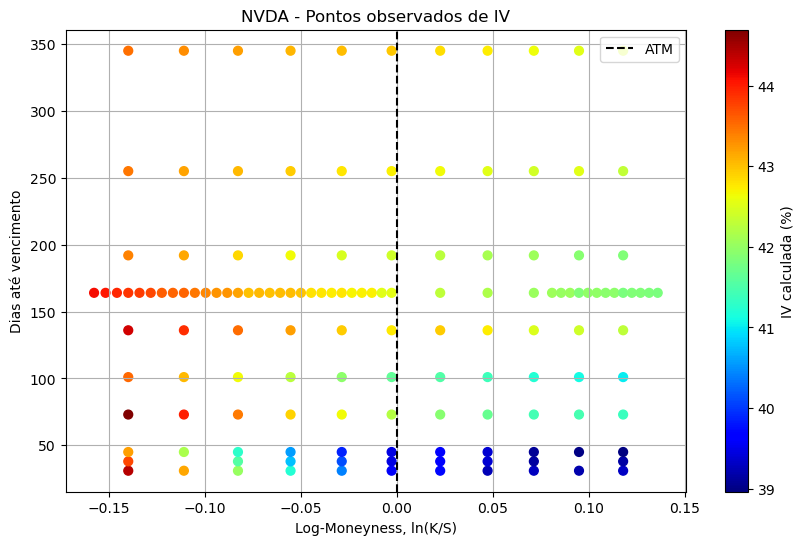

Ranges visuais usados nos gráficos:
Log-Moneyness: [-0.18782230439079095, 0.16582993504749385]
Days to Maturity: [1, 375]
Calculated IV (%): [36, 46]


,expiration,days_to_maturity,T,option_type,contractSymbol,strike,spot,moneyness,log_moneyness,bid,ask,mid,spread_pct,volume,openInterest,iv_calculated,iv_calculated_pct,total_variance
0,2026-08-07,31,0.084932,put,NVDA260807P00170000,170.0,195.550003,0.869343,-0.140018,1.55,1.63,1.590,0.050314,481.0,1041.0,0.444222,44.422214,0.016760
1,2026-08-07,31,0.084932,put,NVDA260807P00175000,175.0,195.550003,0.894912,-0.111030,2.25,2.33,2.290,0.034934,997.0,1262.0,0.431686,43.168604,0.015827
2,2026-08-07,31,0.084932,put,NVDA260807P00180000,180.0,195.550003,0.920481,-0.082859,3.20,3.30,3.250,0.030769,797.0,10319.0,0.420233,42.023285,0.014999
3,2026-08-07,31,0.084932,put,NVDA260807P00185000,185.0,195.550003,0.946050,-0.055460,4.50,4.65,4.575,0.032787,584.0,6877.0,0.412018,41.201781,0.014418
4,2026-08-07,31,0.084932,put,NVDA260807P00190000,190.0,195.550003,0.971618,-0.028792,6.20,6.35,6.275,0.023904,206.0,1902.0,0.404124,40.412361,0.013871
5,2026-08-07,31,0.084932,put,NVDA260807P00195000,195.0,195.550003,0.997187,-0.002817,8.25,8.50,8.375,0.029851,305.0,1133.0,0.395882,39.588221,0.013311
6,2026-08-07,31,0.084932,call,NVDA260807C00200000,200.0,195.550003,1.022756,0.022501,7.30,7.40,7.350,0.013605,1248.0,2169.0,0.397186,39.718577,0.013399
7,2026-08-07,31,0.084932,call,NVDA260807C00205000,205.0,195.550003,1.048325,0.047194,5.35,5.45,5.400,0.018519,1315.0,605.0,0.392475,39.247534,0.013083
8,2026-08-07,31,0.084932,call,NVDA260807C00210000,210.0,195.550003,1.073894,0.071291,3.90,4.00,3.950,0.025316,980.0,1090.0,0.392966,39.296632,0.013115
9,2026-08-07,31,0.084932,call,NVDA260807C00215000,215.0,195.550003,1.099463,0.094822,2.77,2.84,2.805,0.024955,1576.0,807.0,0.391889,39.188946,0.013044


In [19]:
# ============================================================
# Volatility Surface NVDA
# Opções OTM + IV calculada manualmente + filtros conservadores
# Suavização por variância total implícita
# Visual estilo artigo acadêmico, com malha na superfície
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from tqdm import tqdm
from datetime import date, datetime
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import SmoothBivariateSpline

# ============================================================
# 1. Parâmetros principais
# ============================================================

ticker = "NVDA"

asset = yf.Ticker(ticker)

expirations = asset.options

spot = asset.history(period="1d")["Close"].iloc[-1]

print(f"Ticker: {ticker}")
print(f"Spot: {spot:.2f}")
print(f"Número de vencimentos disponíveis: {len(expirations)}")

# Taxa livre de risco aproximada
r = 0.04

# Dividend yield aproximado
q = 0.00

# ============================================================
# 2. Parâmetros conservadores de filtro
# ============================================================

# Moneyness: K/S
min_moneyness = 0.85
max_moneyness = 1.15

# Vencimentos
min_days_to_maturity = 30
max_days_to_maturity = 365

# Liquidez
max_spread_pct = 0.15
min_open_interest = 100
min_volume = 1

# Faixa aceitável de IV calculada para limpeza dos dados
# Aqui eu deixei um pouco mais amplo que o gráfico para não matar pontos úteis da spline.
min_iv_pct = 25
max_iv_pct = 60

# Suavização da variância total
smoothing_parameter = 0.005

# ============================================================
# 3. Parâmetros visuais dos gráficos
# ============================================================

# Faixa visual do eixo Z, como você pediu
z_visual_min = 36
z_visual_max = 46

# Margens visuais nos outros eixos
x_visual_margin = 0.03
y_visual_margin = 30

# Resolução da malha
# Quanto menor, mais "quadriculada" fica a superfície.
# Para ficar parecido com artigo, não use 120 ou 200.
grid_size = 35

# ============================================================
# 4. Funções Black-Scholes
# ============================================================

def black_scholes_price(S, K, T, r, sigma, option_type="call", q=0.0):
    """
    Calcula o preço Black-Scholes de uma call ou put europeia
    com dividend yield contínuo.
    """

    if T <= 0 or sigma <= 0:
        return np.nan

    d1 = (
        np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = (
            S * np.exp(-q * T) * norm.cdf(d1)
            - K * np.exp(-r * T) * norm.cdf(d2)
        )

    elif option_type == "put":
        price = (
            K * np.exp(-r * T) * norm.cdf(-d2)
            - S * np.exp(-q * T) * norm.cdf(-d1)
        )

    else:
        raise ValueError("option_type deve ser 'call' ou 'put'.")

    return price


def implied_volatility(market_price, S, K, T, r, option_type="call", q=0.0):
    """
    Calcula a volatilidade implícita invertendo Black-Scholes.
    """

    if market_price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    def objective_function(sigma):
        return black_scholes_price(
            S=S,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            option_type=option_type,
            q=q
        ) - market_price

    try:
        iv = brentq(
            objective_function,
            1e-6,
            5.0,
            maxiter=1000
        )

        return iv

    except Exception:
        return np.nan

# ============================================================
# 5. Baixar opções OTM de todos os vencimentos
# ============================================================

surface_data_list = []

for expiration in tqdm(expirations):

    try:
        expiration_date = datetime.strptime(expiration, "%Y-%m-%d").date()

        days_to_maturity = (expiration_date - date.today()).days

        T = days_to_maturity / 365

        if days_to_maturity < min_days_to_maturity:
            continue

        if days_to_maturity > max_days_to_maturity:
            continue

        chain = asset.option_chain(expiration)

        calls = chain.calls.copy()
        puts = chain.puts.copy()

        # ====================================================
        # Calls OTM: K > S
        # ====================================================

        calls["option_type"] = "call"
        calls["expiration"] = expiration
        calls["days_to_maturity"] = days_to_maturity
        calls["T"] = T
        calls["spot"] = spot

        calls["strike"] = calls["strike"].astype(float)
        calls["mid"] = (calls["bid"] + calls["ask"]) / 2
        calls["spread"] = calls["ask"] - calls["bid"]
        calls["spread_pct"] = calls["spread"] / calls["mid"]
        calls["moneyness"] = calls["strike"] / spot
        calls["log_moneyness"] = np.log(calls["moneyness"])

        calls_otm = calls[
            (calls["strike"] > spot) &
            (calls["moneyness"] >= 1.00) &
            (calls["moneyness"] <= max_moneyness) &
            (calls["bid"] > 0) &
            (calls["ask"] > 0) &
            (calls["mid"] > 0) &
            (calls["spread_pct"] > 0) &
            (calls["spread_pct"] <= max_spread_pct) &
            (calls["openInterest"].fillna(0) >= min_open_interest) &
            (calls["volume"].fillna(0) >= min_volume)
        ].copy()

        # ====================================================
        # Puts OTM: K < S
        # ====================================================

        puts["option_type"] = "put"
        puts["expiration"] = expiration
        puts["days_to_maturity"] = days_to_maturity
        puts["T"] = T
        puts["spot"] = spot

        puts["strike"] = puts["strike"].astype(float)
        puts["mid"] = (puts["bid"] + puts["ask"]) / 2
        puts["spread"] = puts["ask"] - puts["bid"]
        puts["spread_pct"] = puts["spread"] / puts["mid"]
        puts["moneyness"] = puts["strike"] / spot
        puts["log_moneyness"] = np.log(puts["moneyness"])

        puts_otm = puts[
            (puts["strike"] < spot) &
            (puts["moneyness"] >= min_moneyness) &
            (puts["moneyness"] <= 1.00) &
            (puts["bid"] > 0) &
            (puts["ask"] > 0) &
            (puts["mid"] > 0) &
            (puts["spread_pct"] > 0) &
            (puts["spread_pct"] <= max_spread_pct) &
            (puts["openInterest"].fillna(0) >= min_open_interest) &
            (puts["volume"].fillna(0) >= min_volume)
        ].copy()

        options_otm = pd.concat(
            [puts_otm, calls_otm],
            ignore_index=True
        )

        if len(options_otm) == 0:
            continue

        surface_data_list.append(options_otm)

    except Exception as e:
        print(f"Erro no vencimento {expiration}: {e}")

# ============================================================
# 6. Consolidar base
# ============================================================

if len(surface_data_list) == 0:
    raise ValueError(
        "Nenhuma opção passou nos filtros. "
        "Tente reduzir min_open_interest, aumentar max_spread_pct ou remover min_volume."
    )

surface_df = pd.concat(surface_data_list, ignore_index=True)

surface_df = surface_df.sort_values(
    by=["days_to_maturity", "strike"]
).reset_index(drop=True)

print(f"Número de opções após filtros iniciais: {len(surface_df)}")

# ============================================================
# 7. Calcular IV manualmente
# ============================================================

surface_df["iv_calculated"] = surface_df.apply(
    lambda row: implied_volatility(
        market_price=row["mid"],
        S=row["spot"],
        K=row["strike"],
        T=row["T"],
        r=r,
        option_type=row["option_type"],
        q=q
    ),
    axis=1
)

surface_df = surface_df[
    surface_df["iv_calculated"].notna() &
    (surface_df["iv_calculated"] > 0)
].copy()

surface_df["iv_calculated_pct"] = surface_df["iv_calculated"] * 100

# ============================================================
# 8. Limpeza final da IV
# ============================================================

surface_df = surface_df[
    (surface_df["iv_calculated_pct"] >= min_iv_pct) &
    (surface_df["iv_calculated_pct"] <= max_iv_pct) &
    (surface_df["moneyness"] >= min_moneyness) &
    (surface_df["moneyness"] <= max_moneyness) &
    (surface_df["days_to_maturity"] >= min_days_to_maturity) &
    (surface_df["days_to_maturity"] <= max_days_to_maturity)
].copy()

surface_df = surface_df.sort_values(
    by=["days_to_maturity", "log_moneyness"]
).reset_index(drop=True)

print(f"Número final de opções na superfície: {len(surface_df)}")

if len(surface_df) < 20:
    print(
        "Atenção: poucos pontos após filtros conservadores. "
        "A superfície pode ficar instável. Considere relaxar os filtros."
    )

# ============================================================
# 9. Diagnóstico por vencimento
# ============================================================

summary = surface_df.groupby("expiration").agg(
    n_options=("contractSymbol", "count"),
    min_days=("days_to_maturity", "min"),
    max_days=("days_to_maturity", "max"),
    min_moneyness=("moneyness", "min"),
    max_moneyness=("moneyness", "max"),
    avg_iv_pct=("iv_calculated_pct", "mean"),
    min_iv_pct=("iv_calculated_pct", "min"),
    max_iv_pct=("iv_calculated_pct", "max"),
    avg_spread_pct=("spread_pct", "mean"),
    avg_open_interest=("openInterest", "mean")
).reset_index()

display(summary)

# ============================================================
# 10. Manter apenas vencimentos com número mínimo de pontos
# ============================================================

min_options_per_expiration = 6

valid_expirations = summary[
    summary["n_options"] >= min_options_per_expiration
]["expiration"]

surface_df = surface_df[
    surface_df["expiration"].isin(valid_expirations)
].copy()

print(f"Número de opções após filtro por vencimento: {len(surface_df)}")
print(f"Número de vencimentos usados: {surface_df['expiration'].nunique()}")

if surface_df["expiration"].nunique() < 3:
    print(
        "Atenção: poucos vencimentos disponíveis após os filtros. "
        "A superfície 3D pode ficar pouco informativa."
    )

# ============================================================
# 11. Calcular variância total implícita
# ============================================================
#
# Total variance = sigma² * T
# É mais estável suavizar variância total do que IV diretamente.
# ============================================================

surface_df["total_variance"] = (
    surface_df["iv_calculated"] ** 2
) * surface_df["T"]

surface_df = surface_df[
    surface_df["total_variance"].notna() &
    (surface_df["total_variance"] > 0)
].copy()

# ============================================================
# 12. Gráfico de diagnóstico dos pontos observados
# ============================================================

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    surface_df["log_moneyness"],
    surface_df["days_to_maturity"],
    c=surface_df["iv_calculated_pct"],
    cmap="jet",
    s=40
)

plt.colorbar(scatter, label="IV calculada (%)")
plt.axvline(0, color="black", linestyle="--", label="ATM")

plt.title(f"{ticker} - Pontos observados de IV")
plt.xlabel("Log-Moneyness, ln(K/S)")
plt.ylabel("Dias até vencimento")
plt.grid()
plt.legend()

plt.show()

# ============================================================
# 13. Criar grade regular
# ============================================================

x = surface_df["log_moneyness"].values
y = surface_df["days_to_maturity"].values
z = surface_df["total_variance"].values

log_moneyness_grid = np.linspace(
    surface_df["log_moneyness"].min(),
    surface_df["log_moneyness"].max(),
    grid_size
)

maturity_grid = np.linspace(
    surface_df["days_to_maturity"].min(),
    surface_df["days_to_maturity"].max(),
    grid_size
)

LOG_MONEYNESS_GRID, MATURITY_GRID = np.meshgrid(
    log_moneyness_grid,
    maturity_grid
)

# ============================================================
# 14. Suavizar variância total implícita
# ============================================================

spline = SmoothBivariateSpline(
    x,
    y,
    z,
    kx=3,
    ky=3,
    s=smoothing_parameter
)

TOTAL_VAR_GRID = spline.ev(
    LOG_MONEYNESS_GRID.ravel(),
    MATURITY_GRID.ravel()
).reshape(LOG_MONEYNESS_GRID.shape)

# Evitar variância negativa por efeito numérico da spline
TOTAL_VAR_GRID = np.maximum(TOTAL_VAR_GRID, 1e-8)

# ============================================================
# 15. Recuperar IV a partir da variância total
# ============================================================

T_GRID = MATURITY_GRID / 365

IV_GRID = np.sqrt(
    TOTAL_VAR_GRID / T_GRID
) * 100

# Clip da superfície para não estourar visualmente
IV_GRID = np.clip(
    IV_GRID,
    z_visual_min,
    z_visual_max
)

# ============================================================
# 16. Criar ranges visuais ampliados
# ============================================================

x_min = surface_df["log_moneyness"].min()
x_max = surface_df["log_moneyness"].max()

y_min = surface_df["days_to_maturity"].min()
y_max = surface_df["days_to_maturity"].max()

x_range = [
    x_min - x_visual_margin,
    x_max + x_visual_margin
]

y_range = [
    max(0, y_min - y_visual_margin),
    y_max + y_visual_margin
]

z_range = [
    z_visual_min,
    z_visual_max
]

print("Ranges visuais usados nos gráficos:")
print(f"Log-Moneyness: {x_range}")
print(f"Days to Maturity: {y_range}")
print(f"Calculated IV (%): {z_range}")

# ============================================================
# 17. Superfície 3D estilo artigo
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=LOG_MONEYNESS_GRID,
        y=MATURITY_GRID,
        z=IV_GRID,
        colorscale="Jet",
        opacity=1.00,
        colorbar=dict(title="IV (%)"),
        name="Smoothed volatility surface",

        # Malha sobre a superfície, estilo artigo
        contours=dict(
            x=dict(
                show=True,
                color="black",
                width=1,
                highlight=False
            ),
            y=dict(
                show=True,
                color="black",
                width=1,
                highlight=False
            ),
            z=dict(
                show=False
            )
        )
    )
)

fig.update_layout(
    title=f"{ticker} Volatility Surface",
    scene=dict(
        xaxis=dict(
            title="Log-Moneyness, ln(K/S)",
            range=x_range,
            showgrid=True,
            gridcolor="lightgray",
            zeroline=False
        ),
        yaxis=dict(
            title="Days to Maturity",
            range=y_range,
            showgrid=True,
            gridcolor="lightgray",
            zeroline=False
        ),
        zaxis=dict(
            title="Calculated IV (%)",
            range=z_range,
            showgrid=True,
            gridcolor="lightgray",
            zeroline=False
        ),
        camera=dict(
            eye=dict(x=1.7, y=1.7, z=0.9)
        ),
        aspectmode="manual",
        aspectratio=dict(
            x=1.4,
            y=1.2,
            z=0.7
        )
    ),
    width=950,
    height=750,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

# ============================================================
# 18. Superfície 3D estilo artigo + pontos observados
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=LOG_MONEYNESS_GRID,
        y=MATURITY_GRID,
        z=IV_GRID,
        colorscale="Jet",
        opacity=0.85,
        colorbar=dict(title="IV (%)"),
        name="Smoothed volatility surface",

        # Malha sobre a superfície
        contours=dict(
            x=dict(
                show=True,
                color="black",
                width=1,
                highlight=False
            ),
            y=dict(
                show=True,
                color="black",
                width=1,
                highlight=False
            ),
            z=dict(
                show=False
            )
        )
    )
)

fig.add_trace(
    go.Scatter3d(
        x=surface_df["log_moneyness"],
        y=surface_df["days_to_maturity"],
        z=surface_df["iv_calculated_pct"].clip(z_visual_min, z_visual_max),
        mode="markers",
        marker=dict(
            size=4,
            color=surface_df["iv_calculated_pct"],
            colorscale="Jet",
            cmin=z_visual_min,
            cmax=z_visual_max,
            opacity=0.95
        ),
        name="Observed IV"
    )
)

fig.update_layout(
    title=f"{ticker} Volatility Surface with Observed Points",
    scene=dict(
        xaxis=dict(
            title="Log-Moneyness, ln(K/S)",
            range=x_range,
            showgrid=True,
            gridcolor="lightgray",
            zeroline=False
        ),
        yaxis=dict(
            title="Days to Maturity",
            range=y_range,
            showgrid=True,
            gridcolor="lightgray",
            zeroline=False
        ),
        zaxis=dict(
            title="Calculated IV (%)",
            range=z_range,
            showgrid=True,
            gridcolor="lightgray",
            zeroline=False
        ),
        camera=dict(
            eye=dict(x=1.7, y=1.7, z=0.9)
        ),
        aspectmode="manual",
        aspectratio=dict(
            x=1.4,
            y=1.2,
            z=0.7
        )
    ),
    width=950,
    height=750,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

# ============================================================
# 19. Gráfico de contorno
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Contour(
        x=log_moneyness_grid,
        y=maturity_grid,
        z=IV_GRID,
        colorscale="Jet",
        colorbar=dict(title="IV (%)"),
        contours=dict(
            showlabels=True,
            start=z_visual_min,
            end=z_visual_max,
            size=1
        )
    )
)

fig.update_layout(
    title=f"{ticker} Smoothed Volatility Surface - Contour",
    xaxis=dict(
        title="Log-Moneyness, ln(K/S)",
        range=x_range
    ),
    yaxis=dict(
        title="Days to Maturity",
        range=y_range
    ),
    width=900,
    height=650
)

fig.show()

# ============================================================
# 20. Tabela final
# ============================================================

surface_df_final = surface_df[
    [
        "expiration",
        "days_to_maturity",
        "T",
        "option_type",
        "contractSymbol",
        "strike",
        "spot",
        "moneyness",
        "log_moneyness",
        "bid",
        "ask",
        "mid",
        "spread_pct",
        "volume",
        "openInterest",
        "iv_calculated",
        "iv_calculated_pct",
        "total_variance"
    ]
].copy()

surface_df_final.head(30)